# Raport: Symulator Tomografu Komputerowego

#### Skład grupy

Julia Kardasz 160204
Szymon Wójtowicz 

## Specyfikacja i Model
### Biblioteki

In [33]:
import os
import matplotlib.pyplot as plt
from PIL import Image

In [34]:
class StopNotebook(Exception):
    def __init__(self, msg="Brak dodatkowych informacji."):
        self.msg = msg
        
    def _render_traceback_(self):
        return [f"--- NOTATNIK ZATRZYMANY ---", f"Powód: {self.msg}"]

### Zastosowany model tomografu: stożkowy
### Model symulacji pochłaniania i normalizacja

---

## Opis Implementacji i Funkcji

### Wczytywanie plików 

In [35]:
path = "image.bmp"
path = "dot.bmp"

if os.path.exists(path):
    img = Image.open(path).convert('L')
    root, extension = os.path.splitext(path)

    if extension.lower() != ".bmp":
        raise StopNotebook(msg="Zły format pliku")

    width, height = img.size
    print(f"Szerokość: {width} px")
    print(f"Wysokość: {height} px")
else:
    raise StopNotebook(msg="Nie można znaleźć pliku.")

square = False
rectangle = False
if width > height or height > width:
    rectangle = True
    print("Obraz jest prostokątny.")
elif width == height:
    square = True
    print("Obraz jest kwadratowy.")

if not square and not rectangle:
    raise StopNotebook(msg="Niewłaściwy kształt obrazu.")

Szerokość: 179 px
Wysokość: 176 px
Obraz jest prostokątny.


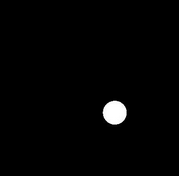

In [36]:
img

### Transformata Radona (Bresenham)

C:\Users\szymw\AppData\Local\Temp\ipykernel_21408\407301290.py:50: RuntimeWarning: overflow encountered in scalar add
  suma+=img[X[j]][Y[j]]


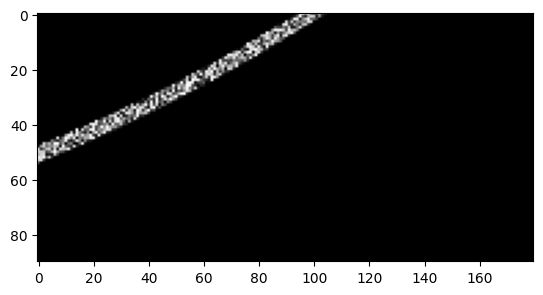

In [37]:
#import sys
#!{sys.executable} -m pip install -U scikit-image
#odkomentuj jeśli nie działa
import numpy as np
import math
from skimage.data import shepp_logan_phantom
from skimage.transform import radon, rescale
from skimage.draw import line_nd

def custom_radon(img,krok):
    m1 = img.shape[0]
    m2 = img.shape[1]
    centerX = m1/2
    centerY = m2/2
    r = math.sqrt(centerX**2+centerY**2)
    sinogram = []
    startX = centerX - r
    startY = centerY

    emiter_pointX = []
    emiter_pointY = []

    receptor_pointX = []
    receptor_pointY = []

    sinusy = []
    cosinusy = []

    for alfa in range(90,270,krok):
        sinus = math.sin(alfa/180*math.pi)
        cosinus = math.cos(alfa/180*math.pi)
        emiter_pointX.append(centerX - r * cosinus)
        emiter_pointY.append(centerY - r * sinus)
        

    for i in range(len(emiter_pointX)):
        line = []
        krok_receptor=1
        scan = []
        for k in range(-90,90,krok_receptor):
            sinus=math.sin(k/180*math.pi)
            cosinus = math.cos(k/180*math.pi)
            X,Y=line_nd((emiter_pointX[i],emiter_pointY[i]),(emiter_pointX[i] + 2*r * sinus,emiter_pointY[i] + 2*r*cosinus))
            #print(len(X),len(Y))
            maxX = img.shape[0]
            maxY = img.shape[1]
            suma=0
            for j in range(len(X)):
                if X[j]<maxX and Y[j]<maxY and X[j]>=0 and Y[j] >=0:
                    suma+=img[X[j]][Y[j]]
            line.append(suma)
        sinogram.append(line)
        line = []
    maxlen = 0
    for i in range(len(sinogram)):
        if len(sinogram[i])>maxlen:
            maxlen=len(sinogram[i])
    for i in range(len(sinogram)):
        while len(sinogram[i])<maxlen:
            sinogram[i].append(0)
    return sinogram


image = np.array(img)
#print(radon(image, theta=np.linspace(0,180,max(image.shape), endpoint=False))[0])
sinogram = custom_radon(image,krok=2)

plt.imshow(sinogram,cmap=plt.cm.Greys_r)

### Filtrowanie sinogramu i splot 


### Przetwarzanie końcowe i wyznaczanie jasności pikseli


In [38]:
from skimage.transform import iradon
result = iradon(sinogram, theta=np.linspace(0,180,max(image.shape), endpoint=False))
plt.imshow(result,cmap=plt.cm.Greys_r)

AttributeError: 'list' object has no attribute 'ndim'

### Wyznaczanie miary RMSE 


### Obsługa plików DICOM



---

## Przykłady Działania Programu

### Przypadek testowy 1
* **Obraz wejściowy:**
* **Sinogram:**
* **Obraz wyjściowy (rekonstrukcja):**

### Przypadek testowy 2 (z filtrowaniem)
* **Obraz wejściowy:**
* **Obraz wyjściowy bez filtra:**
* **Obraz wyjściowy z filtrem:**

---


## Analiza Statystyczna i Wyniki Eksperymentów

### 1. Wpływ liczby detektorów na RMSE (90 - 720)
* **Wykres:**
* **Komentarz:**

### 2. Wpływ liczby skanów na RMSE (90 - 720)
* **Wykres:**
* **Komentarz:**

### 3. Wpływ rozpiętości układu na RMSE (45° - 270°)
* **Wykres:**
* **Komentarz:**

### 4. Porównanie wpływu filtrowania (360 det., 360 skanów, 270°)
* **Tabela wyników RMSE:**
* **Komentarz i subiektywna ocena jakości:**

---
